In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")

df = pd.read_csv("data/deliveries.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(150460, 21)
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


C:\Users\ANSH\AppData\Local\Temp\ipykernel_23968\3272944966.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_batsmen, x='Total Runs', y='Batsman', palette='Blues_r')


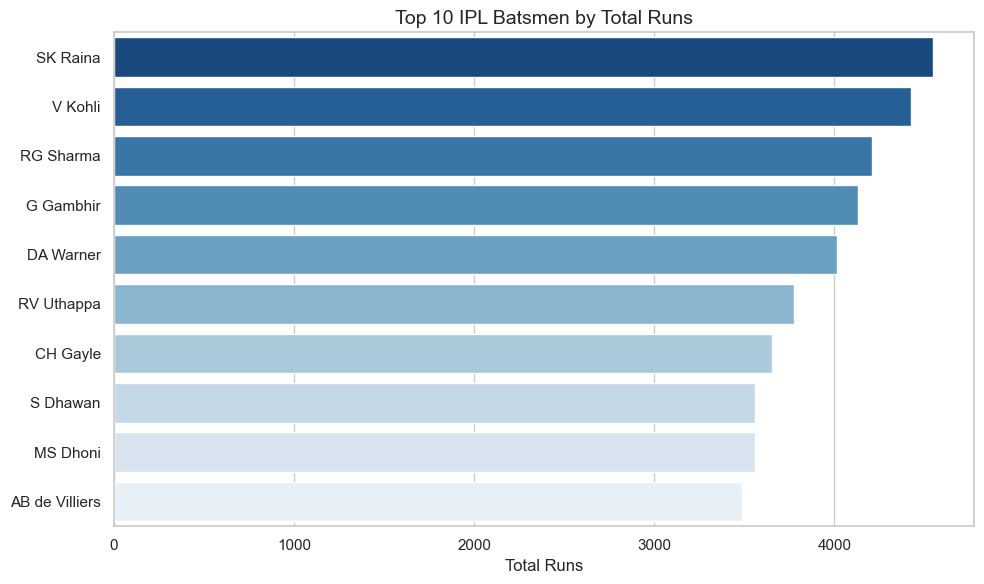

          Batsman  Total Runs
0        SK Raina        4548
1         V Kohli        4423
2       RG Sharma        4207
3       G Gambhir        4132
4       DA Warner        4014
5      RV Uthappa        3778
6        CH Gayle        3651
7        S Dhawan        3561
8        MS Dhoni        3560
9  AB de Villiers        3486


In [9]:
# Question 1 - Top 10 batsmen by total runs

top_batsmen = df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending = False).head(10).reset_index()
top_batsmen.columns = ['Batsman', 'Total Runs']

plt.figure(figsize=(10,6))
sns.barplot(data=top_batsmen, x='Total Runs', y='Batsman', palette='Blues_r')

plt.title('Top 10 IPL Batsmen by Total Runs', fontsize=14)
plt.xlabel('Total Runs')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top_batsmen.png', dpi=150)
plt.show()

print(top_batsmen)

**Finding:** Suresh Raina leads all IPL batsmen in total runs scored between 4500-4600,
ahead of Virat kholi and Rg sharma. This reflects his exceptional 
consistency across all seasons he played, making him one of IPL's most reliable performers.

C:\Users\ANSH\AppData\Local\Temp\ipykernel_23968\3890241860.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_bowlers, x = 'Total Wickets', y = 'Bowler', palette = 'Reds_r')


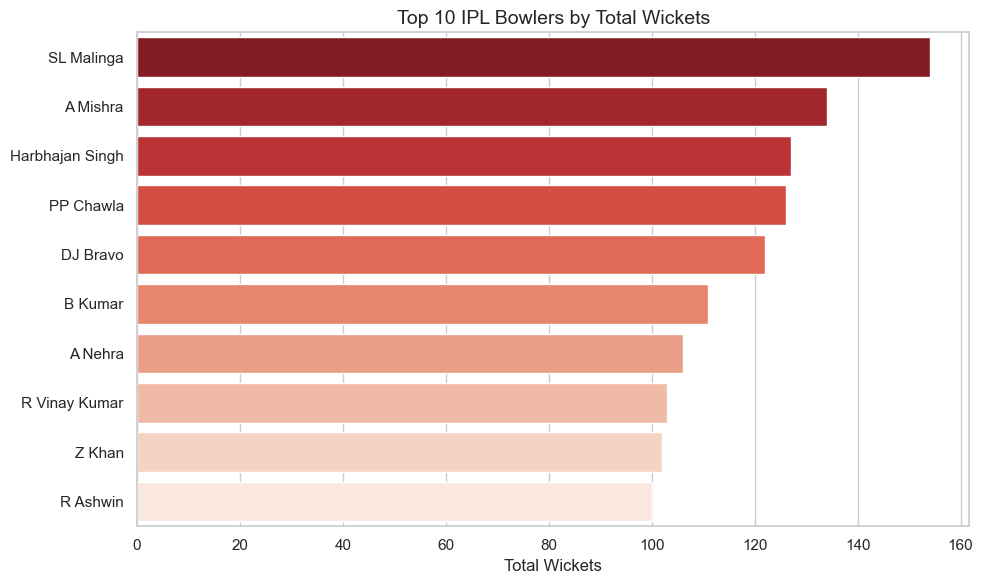

            Bowler  Total Wickets
0       SL Malinga            154
1         A Mishra            134
2  Harbhajan Singh            127
3        PP Chawla            126
4         DJ Bravo            122
5          B Kumar            111
6          A Nehra            106
7    R Vinay Kumar            103
8           Z Khan            102
9         R Ashwin            100


In [10]:
# Question 2 - Top 10 bowlers by total wickets

wickets_df = df[df['player_dismissed'].notna()]
wickets_df = wickets_df[~wickets_df['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]

top_bowlers = wickets_df.groupby('bowler')['player_dismissed'].count().sort_values(ascending = False).head(10).reset_index()
top_bowlers.columns = ['Bowler', 'Total Wickets']

plt.figure(figsize=(10,6))
sns.barplot(data = top_bowlers, x = 'Total Wickets', y = 'Bowler', palette = 'Reds_r')

plt.title('Top 10 IPL Bowlers by Total Wickets', fontsize = 14)
plt.xlabel('Total Wickets')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top_bowlers.png', dpi = 150)
plt.show()

print(top_bowlers)


**Finding:** Lasith Malinga is the highest wicket-taker in IPL history, 
renowned for his unorthodox slinging action and lethal yorkers.

C:\Users\ANSH\AppData\Local\Temp\ipykernel_23968\643845635.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = avg_team_runs, x = 'Average Runs per Match', y = 'Team', palette = 'Greens_r')


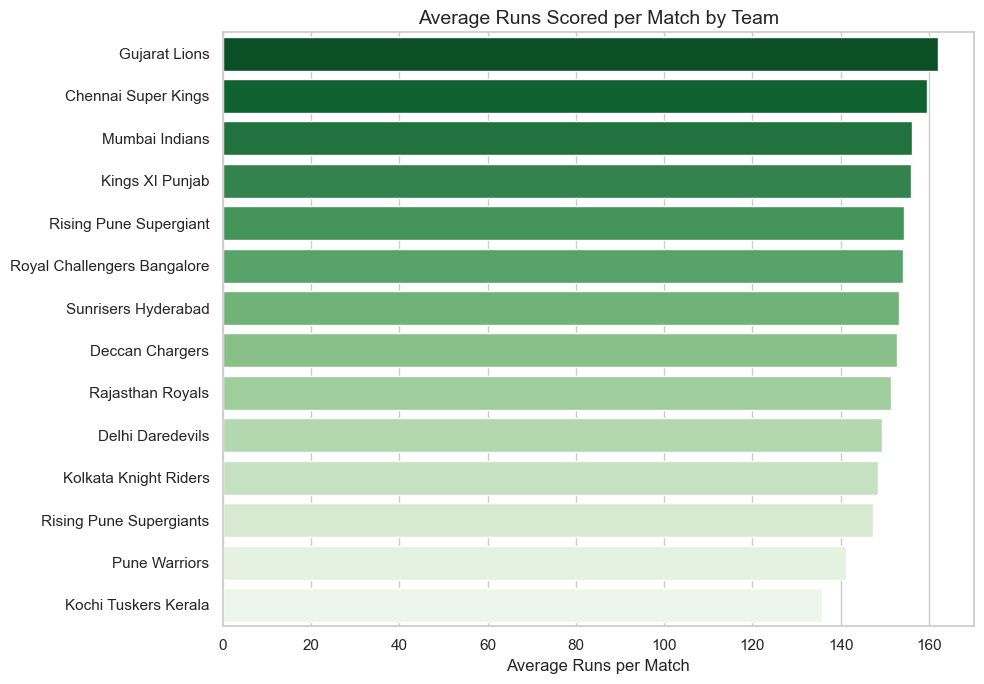

                           Team  Average Runs per Match
0                 Gujarat Lions                   162.1
1           Chennai Super Kings                   159.5
2                Mumbai Indians                   156.2
3               Kings XI Punjab                   155.9
4        Rising Pune Supergiant                   154.4
5   Royal Challengers Bangalore                   154.2
6           Sunrisers Hyderabad                   153.3
7               Deccan Chargers                   152.8
8              Rajasthan Royals                   151.3
9              Delhi Daredevils                   149.3
10        Kolkata Knight Riders                   148.4
11      Rising Pune Supergiants                   147.4
12                Pune Warriors                   141.3
13         Kochi Tuskers Kerala                   135.8


In [12]:
# Question 3 - Average runs scored per match by team

team_runs = df.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()
avg_team_runs = team_runs.groupby('batting_team')['total_runs'].mean().sort_values(ascending = False).reset_index()
avg_team_runs.columns = ['Team', 'Average Runs per Match']
avg_team_runs['Average Runs per Match'] = avg_team_runs['Average Runs per Match'].round(1)

plt.figure(figsize=(10,7))
sns.barplot(data = avg_team_runs, x = 'Average Runs per Match', y = 'Team', palette = 'Greens_r')

plt.title('Average Runs Scored per Match by Team', fontsize = 14)
plt.xlabel('Average Runs per Match')
plt.ylabel('')
plt.tight_layout()
plt.savefig('avg_team_runs.png', dpi = 150)
plt.show()

print(avg_team_runs)



**Finding:** Gujarat Lions have the highest average runs per match.


C:\Users\ANSH\AppData\Local\Temp\ipykernel_23968\897464645.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=economical, x='economy', y='bowler', palette='Purples_r')


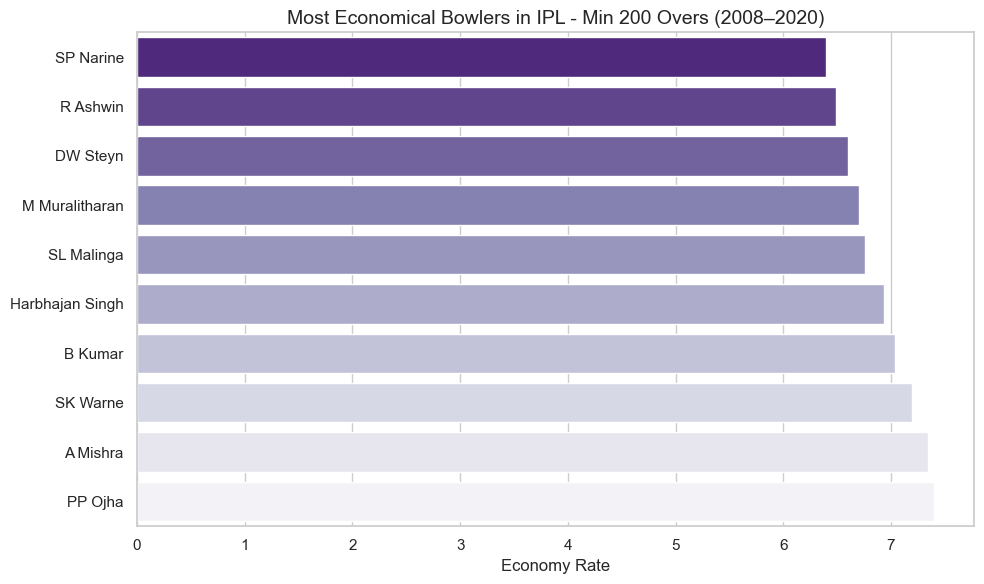

              bowler       overs  economy
300        SP Narine  326.000000     6.40
234         R Ashwin  393.166667     6.49
103         DW Steyn  359.833333     6.60
181   M Muralitharan  263.500000     6.70
294       SL Malinga  449.000000     6.76
117  Harbhajan Singh  498.166667     6.93
50           B Kumar  342.333333     7.04
293         SK Warne  203.833333     7.19
5           A Mishra  450.500000     7.34
230          PP Ojha  324.166667     7.40


In [13]:
# Question 4 - Most economical bowlers (min 200 overs bowled)

bowler_stats = df.groupby('bowler').agg(
    total_runs = ('total_runs', 'sum'),
    total_balls = ('ball', 'count')
).reset_index()

bowler_stats['overs'] = bowler_stats['total_balls'] / 6
bowler_stats['economy'] = (bowler_stats['total_runs'] / bowler_stats['overs']).round(2)

economical = bowler_stats[bowler_stats[ 'overs'] >= 200 ].sort_values('economy').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=economical, x='economy', y='bowler', palette='Purples_r')

plt.title('Most Economical Bowlers in IPL - Min 200 Overs (2008–2020)', fontsize=14)
plt.xlabel('Economy Rate')
plt.ylabel('')
plt.tight_layout()
plt.savefig('q4_economical_bowlers.png', dpi=150)
plt.show()

print(economical[['bowler', 'overs', 'economy']])

**Finding:** Sunil Narine is the most economical bowler among 
bowlers with 200+ overs, with an economy of 6.40.

C:\Users\ANSH\AppData\Local\Temp\ipykernel_23968\657558212.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sr, x='strike_rate', y='batsman', palette='Oranges_r')


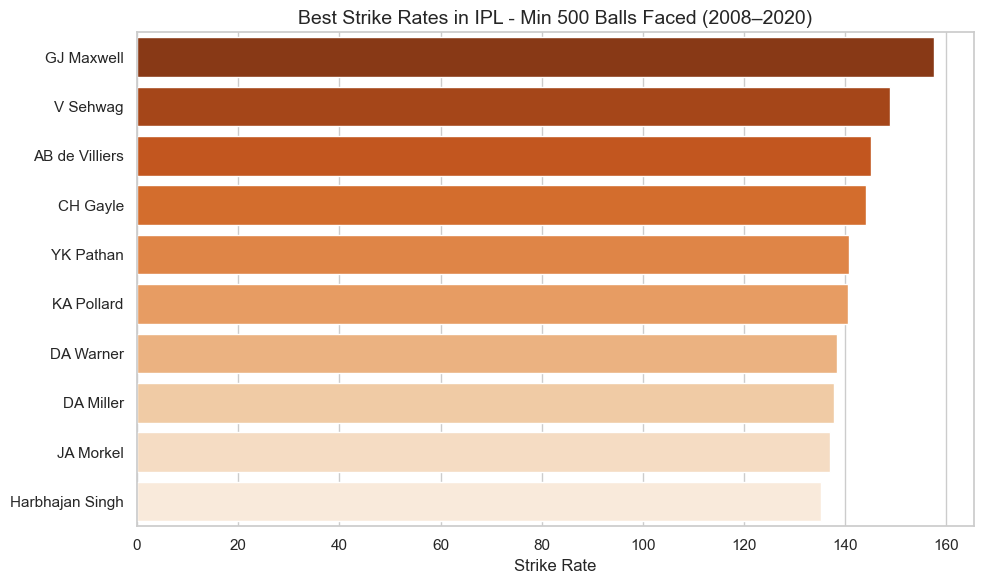

             batsman  balls_faced  total_runs  strike_rate
143       GJ Maxwell          780        1229       157.56
433         V Sehwag         1833        2728       148.83
22    AB de Villiers         2402        3486       145.13
85          CH Gayle         2532        3651       144.19
454        YK Pathan         2076        2922       140.75
190       KA Pollard         1674        2354       140.62
103        DA Warner         2902        4014       138.32
102        DA Miller         1135        1563       137.71
168        JA Morkel          712         975       136.94
151  Harbhajan Singh          591         799       135.19


In [14]:
# Question 5 - Best strike rates among batsmen (min 500 balls faced)

batsman_stats = df.groupby('batsman').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()

batsman_stats['strike_rate'] = ((batsman_stats['total_runs'] / batsman_stats['balls_faced']) * 100).round(2)

top_sr = batsman_stats[batsman_stats['balls_faced'] >= 500].sort_values('strike_rate', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_sr, x='strike_rate', y='batsman', palette='Oranges_r')

plt.title('Best Strike Rates in IPL - Min 500 Balls Faced (2008–2020)', fontsize=14)
plt.xlabel('Strike Rate')
plt.ylabel('')
plt.tight_layout()
plt.savefig('q5_strike_rate.png', dpi=150)
plt.show()

print(top_sr[['batsman', 'balls_faced', 'total_runs', 'strike_rate']])

**Finding:** Glenn Maxwell has the highest strike rate among IPL batsmen with 
500+ balls faced at 157.56, meaning he scores a run almost every ball.

## Key Findings

1. **Top Batsman:** Suresh Raina leads IPL in total runs, 
   reflecting unmatched consistency across seasons.

2. **Top Bowler:** Lasith Malinga is the highest wicket-taker, 
   famous for his lethal yorkers in death overs.

3. **Best Batting Team:** Gujarat Lions averaged the most runs per match.
   
4. **Most Economical Bowler:** Sunil Narine (economy 6.40) is the hardest 
   bowler to score off among high-volume IPL bowlers.

5. **Best Strike Rate:** Glenn Maxwell (157.56) is the most explosive 
   batsman among those with 500+ balls faced.

In [15]:
print("Analysis Complete!")
print(f"Dataset: {df.shape[0]:,} deliveries across {df['match_id'].nunique()} matches")
print(f"Teams analyzed: {df['batting_team'].nunique()}")
print(f"Batsmen analyzed: {df['batsman'].nunique()}")
print(f"Bowlers analyzed: {df['bowler'].nunique()}")

Analysis Complete!
Dataset: 150,460 deliveries across 636 matches
Teams analyzed: 14
Batsmen analyzed: 461
Bowlers analyzed: 356
